# kNN

In [1]:
%run preprocessing.ipynb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nbimporter

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

testing
     k  Accuracy     Error    Recall  F1 Score  Precision
0    1  0.469584  0.530416  0.469584  0.466959   0.464637
1    3  0.469633  0.530367  0.469633  0.469454   0.473961
2    5  0.502738  0.497262  0.502738  0.492750   0.485192
3   10  0.532932  0.467068  0.532932  0.504356   0.495756
4   20  0.552864  0.447136  0.552864  0.509303   0.515355
5   50  0.565395  0.434605  0.565395  0.505014   0.541329
6  100  0.567369  0.432631  0.567369  0.497391   0.550786
7  200  0.565938  0.434062  0.565938  0.485242   0.556535

training
     k  Accuracy     Error    Recall  F1 Score  Precision
0    1  1.000000  0.000000  1.000000  1.000000   1.000000
1    3  0.722844  0.277156  0.722844  0.725430   0.735136
2    5  0.671308  0.328692  0.671308  0.665855   0.663647
3   10  0.628110  0.371890  0.628110  0.604819   0.614019
4   20  0.601756  0.398244  0.601756  0.562236   0.583614
5   50  0.585319  0.414681  0.585319  0.527861   0.571557
6  100  0.576132  0.423868  0.576132  0.506741   0.562

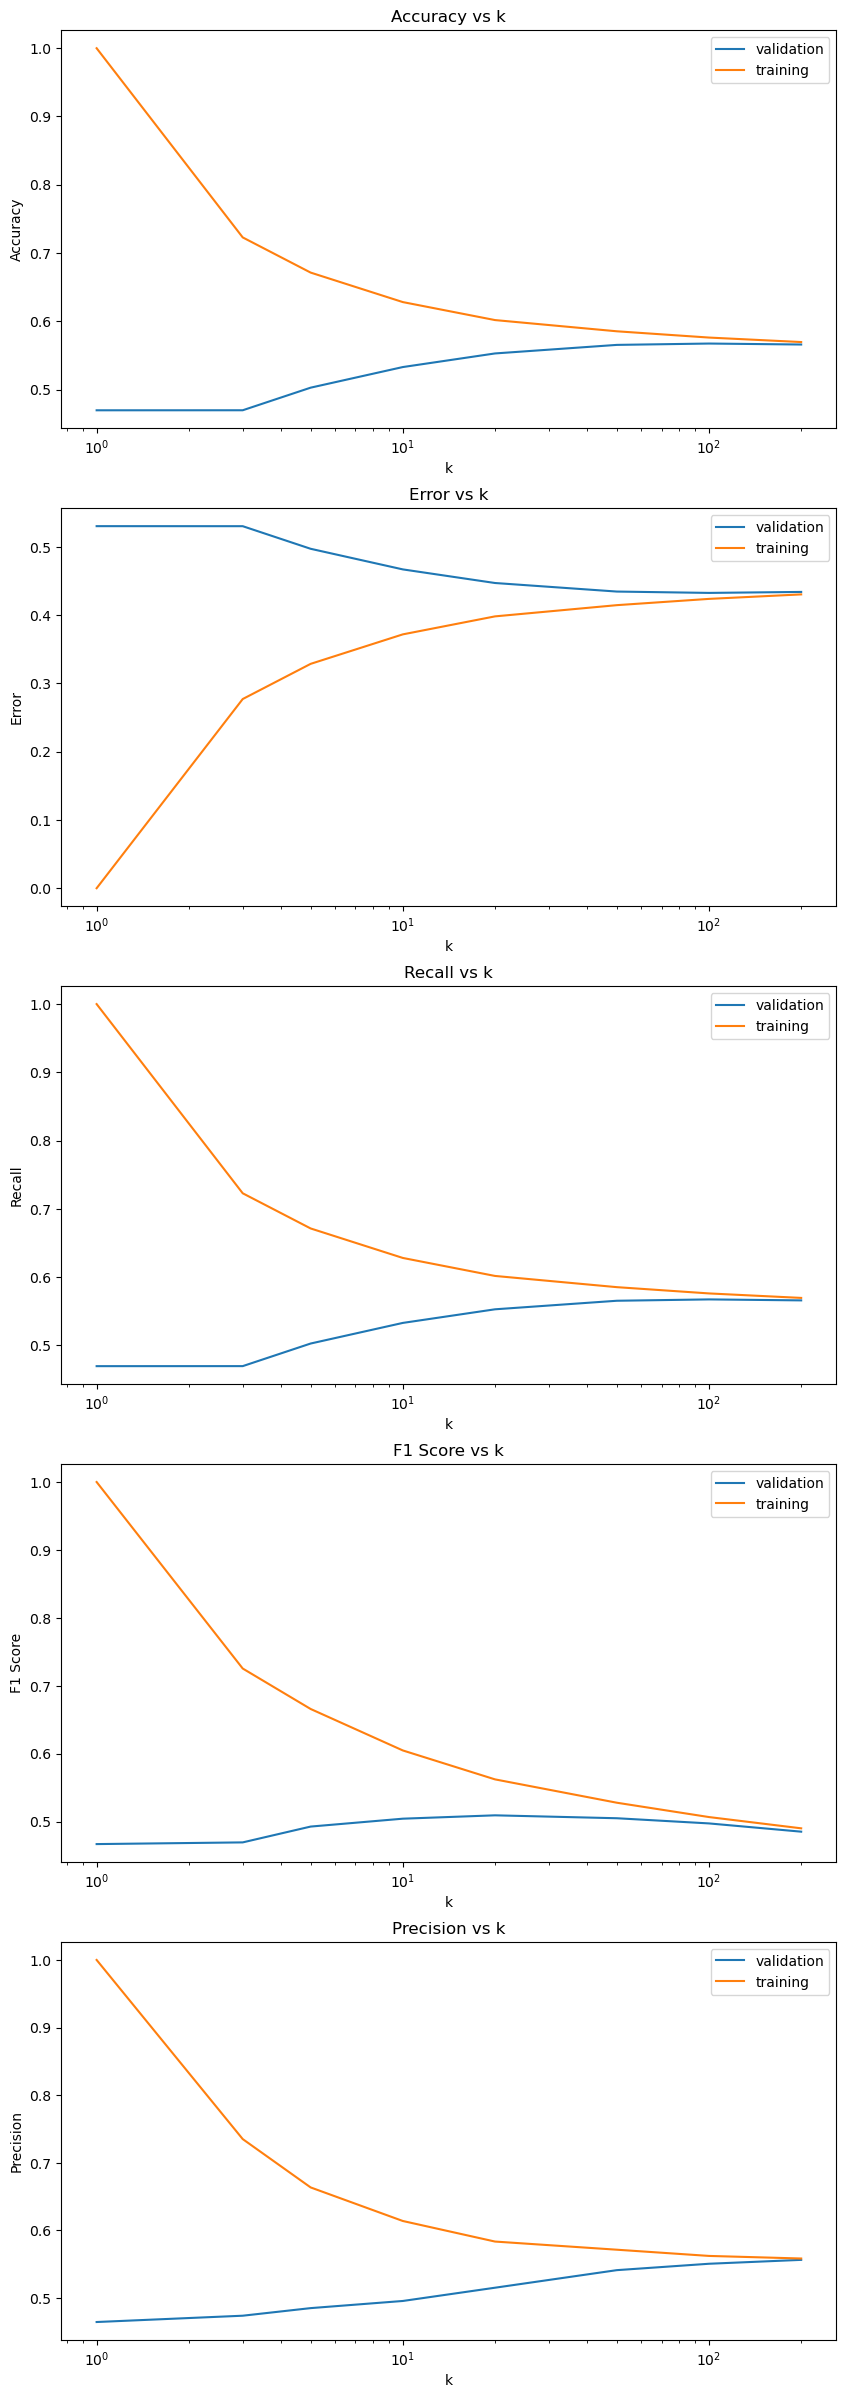

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
import numpy as np

# --- Pipelines ---
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols),
])

# --- Labels ---
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_val   = label_encoder.transform(y_val_raw)
y_test  = label_encoder.transform(y_test_raw)

# --- Encode ---
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)

# --- PCA ---
pca = PCA(n_components=0.95)
X_train_prepared = pca.fit_transform(X_train_enc)
X_val_prepared   = pca.transform(X_val_enc)
X_test_prepared  = pca.transform(X_test_enc)

# --- KNN loop ---
k_vals = [1, 3, 5, 10, 20, 50, 100, 200]
training_errors = []
testing_errors = []

for i in k_vals:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_prepared, y_train)

    # --- TRAIN ---
    y_pred = knn.predict(X_train_prepared)
    acc = accuracy_score(y_train, y_pred)
    training_errors.append({
        "k": i,
        "Accuracy": acc,
        "Error": 1-acc,
        "Recall": recall_score(y_train, y_pred, average='weighted'),
        "F1 Score": f1_score(y_train, y_pred, average='weighted'),
        'Precision': precision_score(y_train, y_pred, average='weighted')
    })

    # --- VALIDATION ---
    y_pred = knn.predict(X_val_prepared)
    acc = accuracy_score(y_val, y_pred)
    testing_errors.append({
        "k": i,
        "Accuracy": acc,
        "Error": 1-acc,
        "Recall": recall_score(y_val, y_pred, average='weighted'),
        "F1 Score": f1_score(y_val, y_pred, average='weighted'),
        'Precision': precision_score(y_val, y_pred, average='weighted')
    })

testing_df = pd.DataFrame(testing_errors)
print('testing')
print(testing_df)
print()
print('training')
training_df = pd.DataFrame(training_errors)
print(training_df)

figure, axes = plt.subplots(5, figsize=(10, 30))

metrics = ['Accuracy', 'Error', 'Recall', 'F1 Score', 'Precision']

for i in range(5):
    value = metrics[i]

    axes[i].set_xlabel("k")
    axes[i].set_ylabel(value)

    axes[i].semilogx(testing_df["k"], testing_df[value], label="validation")
    axes[i].semilogx(training_df["k"], training_df[value], label="training")

    axes[i].set_title(f'{value} vs k')
    axes[i].legend()

In [8]:
knn = KNeighborsClassifier(n_neighbors=100)
knn.fit(X_train_prepared, y_train)
y_pred = knn.predict(X_val_prepared)
recalls = recall_score(y_val, y_pred, average=None)
for label, r in zip(label_encoder.classes_, recalls):
    print(f"Recall for {label}: {r}")

Recall for <30: 0.018785495849716033
Recall for >30: 0.25123898678414097
Recall for NO: 0.898842851810377
